In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered["label"].value_counts())



label
0    18399879
1      100118
Name: count, dtype: int64


In [13]:
pca_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pca/pileup.npz"
with np.load(pca_df, allow_pickle=True) as data:
    pca_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_df = pca_df[pca_df["count_dom"] >= 20]
pca_df = pca_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_df)

                label_id      pm6a  count_pm6a  pca  count_pca  logsum_pca  \
0         NM_000016:1000  0.000000           0  1.0        255 -956.270691   
1         NM_000016:1008  0.000000           0  1.0        256 -889.857605   
2         NM_000016:1009  0.000000           0  1.0        253 -797.323303   
3         NM_000016:1010  0.000000           0  1.0        251 -829.828186   
4         NM_000016:1014  0.000000           0  1.0        251 -846.109802   
...                  ...       ...         ...  ...        ...         ...   
10794116  NR_182669:3964  0.000000           0  1.0         50 -159.479523   
10794117  NR_182669:3965  0.000000           0  1.0         51 -162.836075   
10794118  NR_182669:3966  0.000000           0  1.0         47 -138.327194   
10794119  NR_182669:3968  0.984304           1  1.0         45 -127.156105   
10794120  NR_182669:3969  0.000000           0  1.0         42 -121.713493   

               dom  count_dom  count  logsum_pm6a  depth  label

In [4]:
cell_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup/pileup.pkl"
cell_df = pd.read_pickle(cell_df)
cell_df = cell_df[cell_df["count_pm6a"] >= 20]
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
cell_label_df["discarded_ratio"] = (cell_label_df["count_dom"] - cell_label_df["count_pm6a"]) / cell_label_df["count_dom"]


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


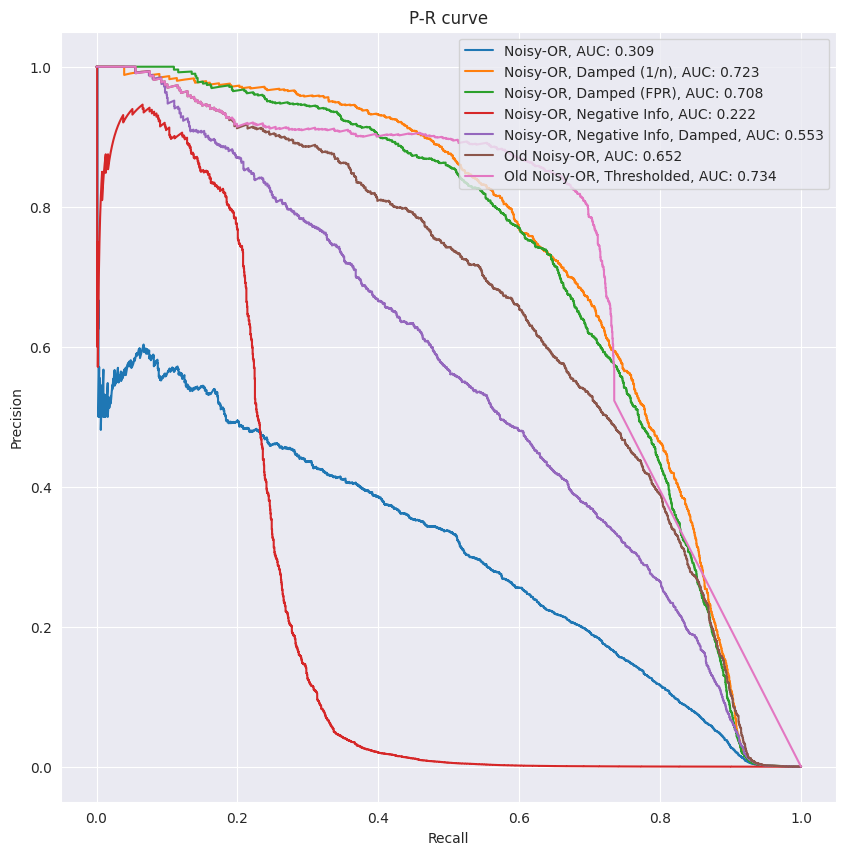

In [14]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"])) 
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, Thresholded, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


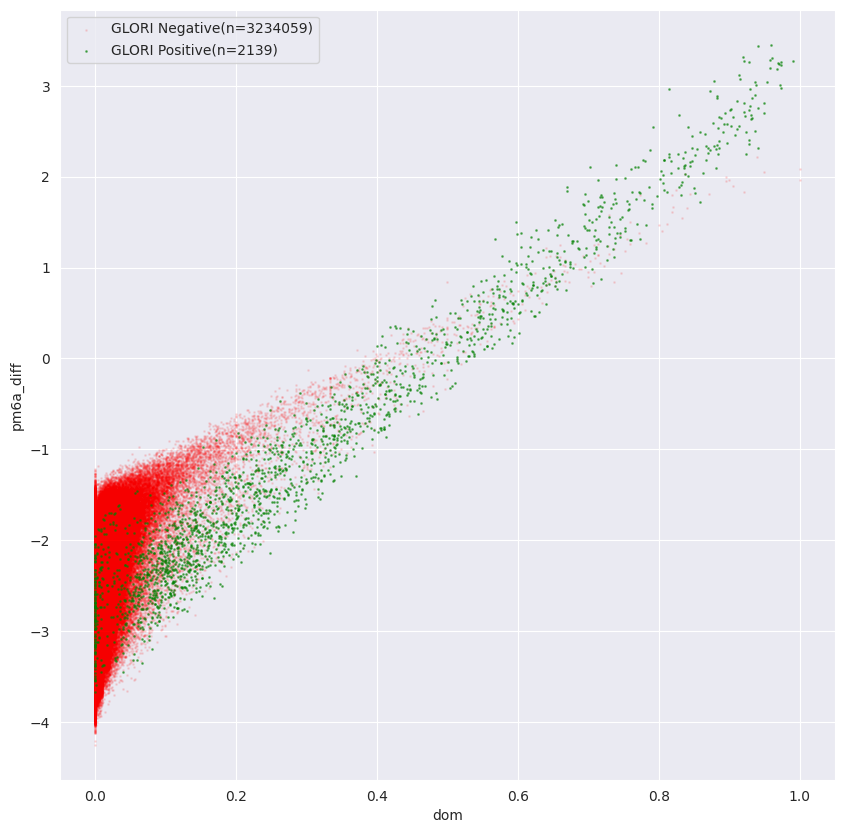

In [15]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

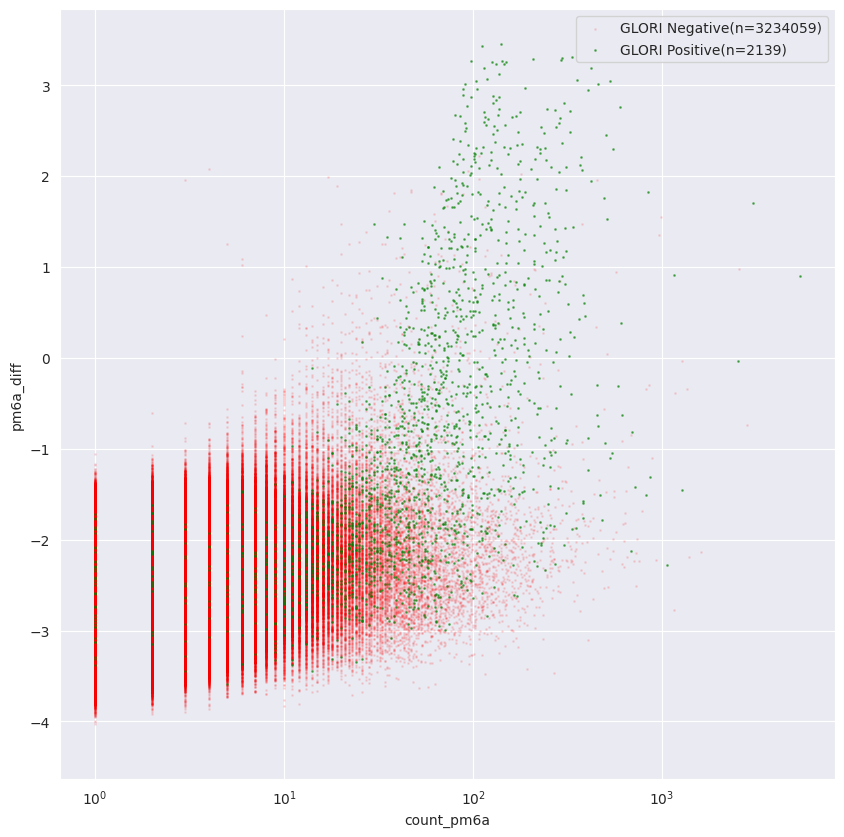

In [16]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("count_pm6a")
ax.set_ylabel("pm6a_diff")
ax.set_xscale("log")
plt.show()
plt.close() 

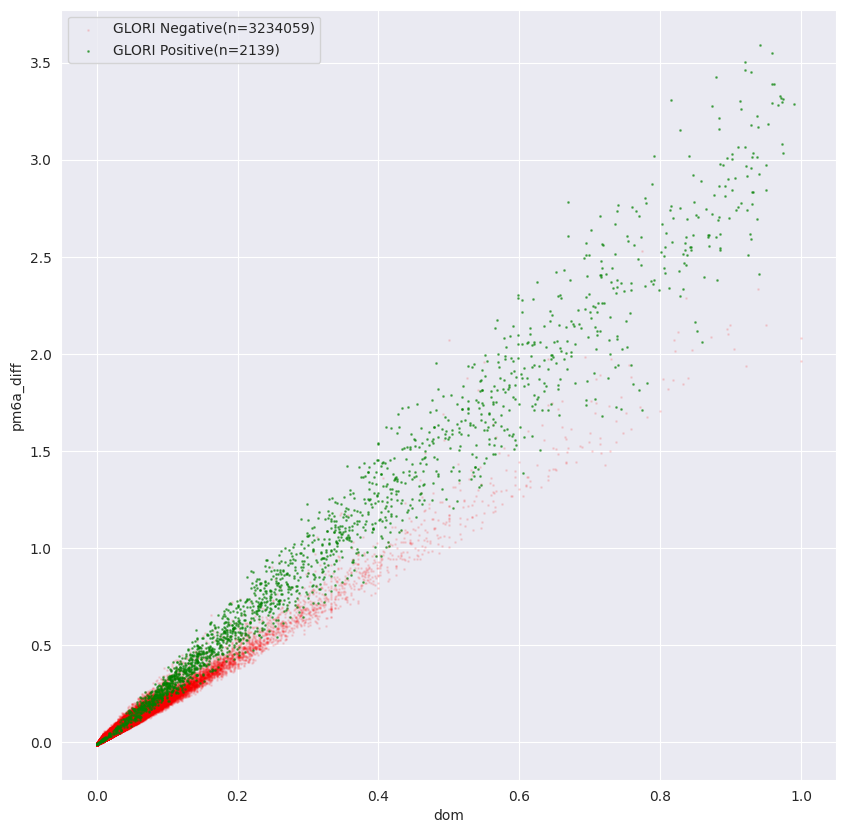

In [17]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

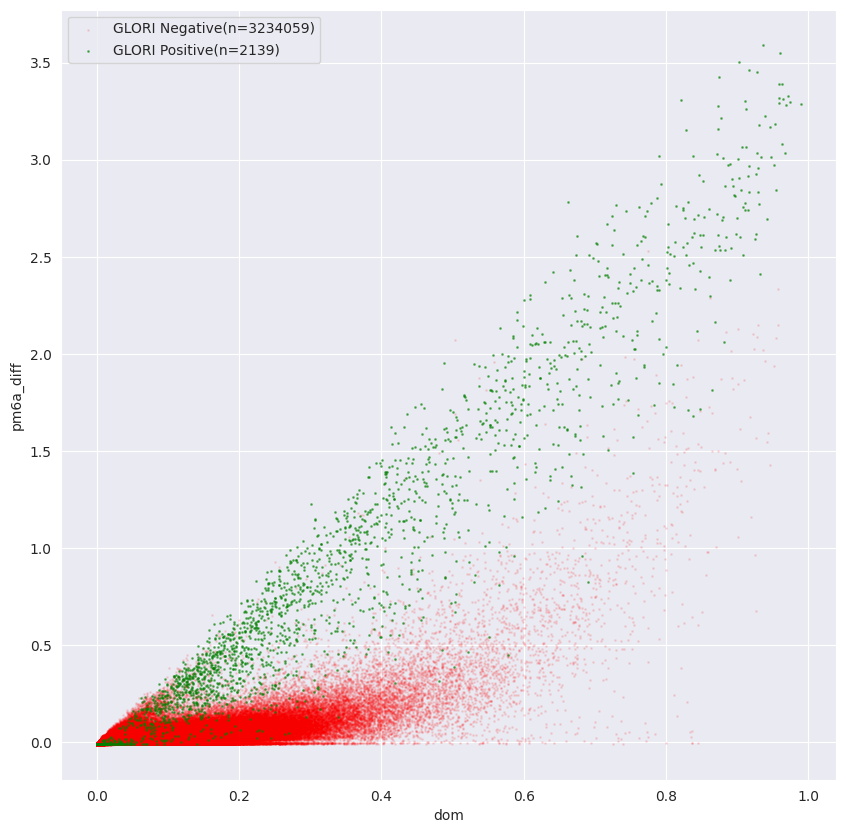

In [18]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

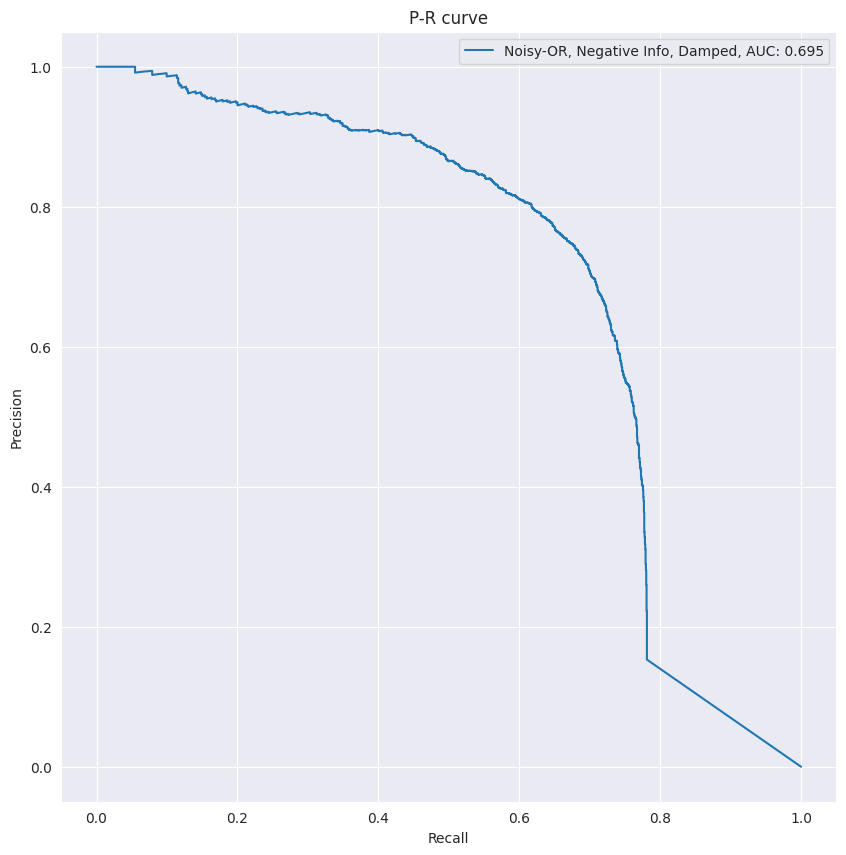

In [19]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)] 
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr
selected_df["threshold"] = -np.log10(fpr) * selected_df["count_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"])
selected_df["pm6a_diff_damp"] = selected_df["pm6a_diff_damp"] * ((selected_df["pm6a_diff_damp"] > selected_df["threshold"]) & (selected_df["dom"] > 0.05))


fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


(array([2.12885275, 0.36346266, 0.48028995, 0.63605966, 0.58413642,
        0.98654152, 0.86971423, 1.05144556, 0.97356071, 0.97356071,
        0.84375261, 0.72692533, 0.76586776, 0.70096371, 0.44134752,
        0.72692533, 0.62307885, 0.48028995, 0.36346266, 0.55817481,
        0.62307885, 0.33750105, 0.48028995, 0.38942428, 0.42836671,
        0.22067376, 0.36346266, 0.35048185, 0.25961619, 0.32452024,
        0.35048185, 0.29855862, 0.31153943, 0.24663538, 0.28557781,
        0.272597  , 0.1427889 , 0.22067376, 0.29855862, 0.18173133,
        0.23365457, 0.09086567, 0.23365457, 0.22067376, 0.20769295,
        0.25961619, 0.11682728, 0.23365457, 0.22067376, 0.20769295,
        0.15576971, 0.18173133, 0.15576971, 0.1427889 , 0.15576971,
        0.19471214, 0.10384648, 0.19471214, 0.09086567, 0.15576971,
        0.09086567, 0.10384648, 0.05192324, 0.10384648, 0.10384648,
        0.10384648, 0.1427889 , 0.10384648, 0.07788486, 0.09086567,
        0.10384648, 0.1427889 , 0.15576971, 0.02

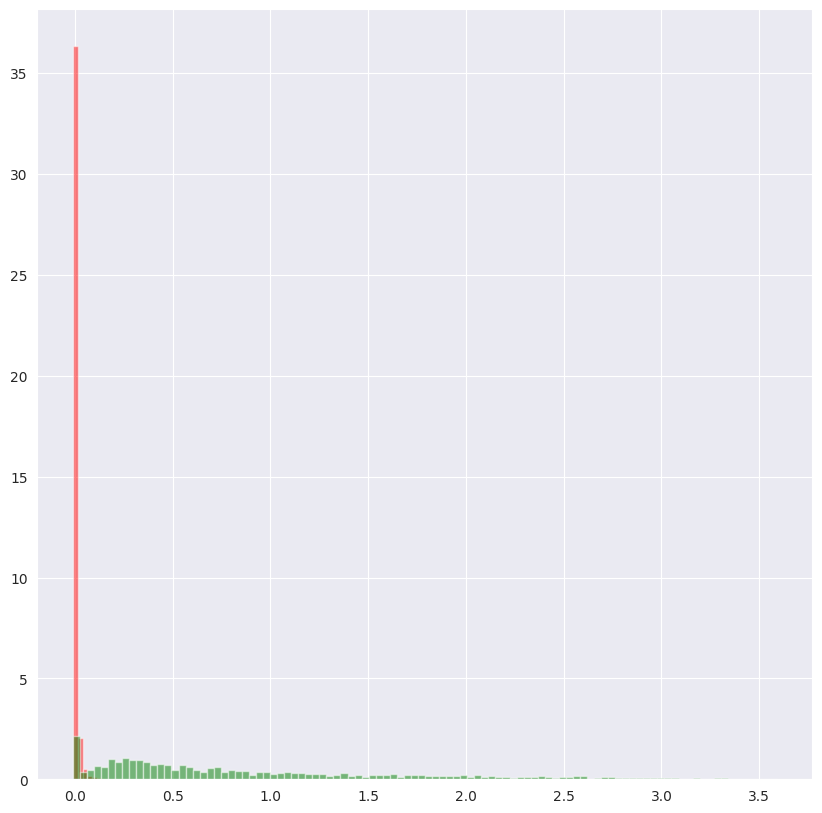

In [20]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hist(neg_df["pm6a_diff"], bins=100, alpha=0.5, color="red", label=f"GLORI Negative(n={len(neg_df)})", density=True)
ax.hist(pos_df["pm6a_diff"], bins=100, alpha=0.5, color="green", label=f"GLORI Positive(n={len(pos_df)})", density=True)

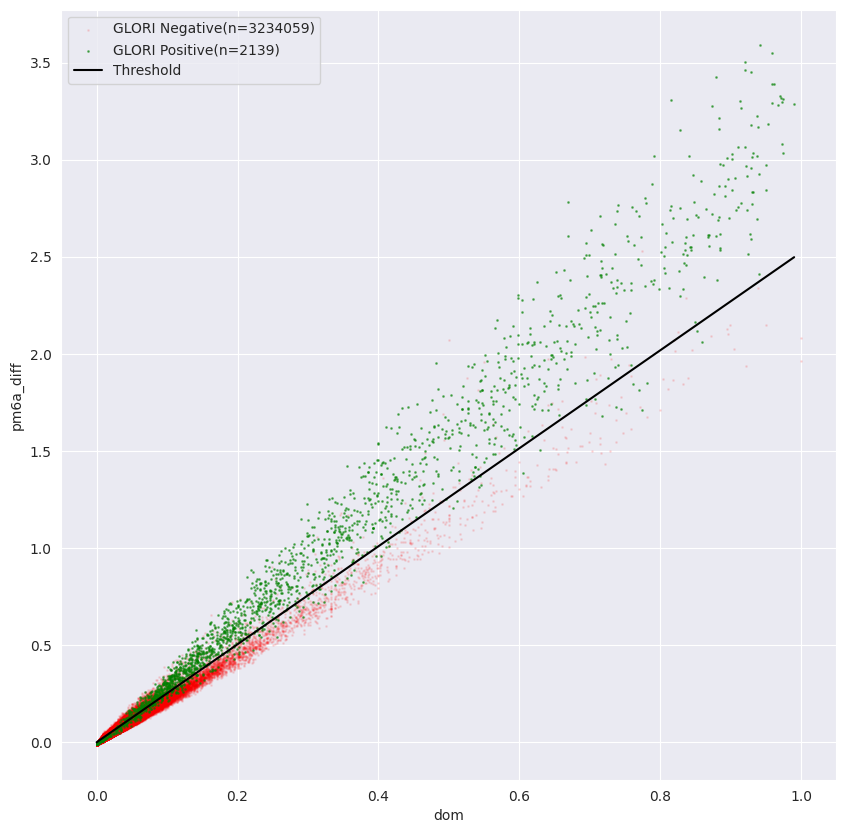

In [24]:
fpr = 0.003
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

x = np.arange(0,1,0.01)
y = -np.log10(fpr) * x

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.plot(x, y, color="black", label="Threshold")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

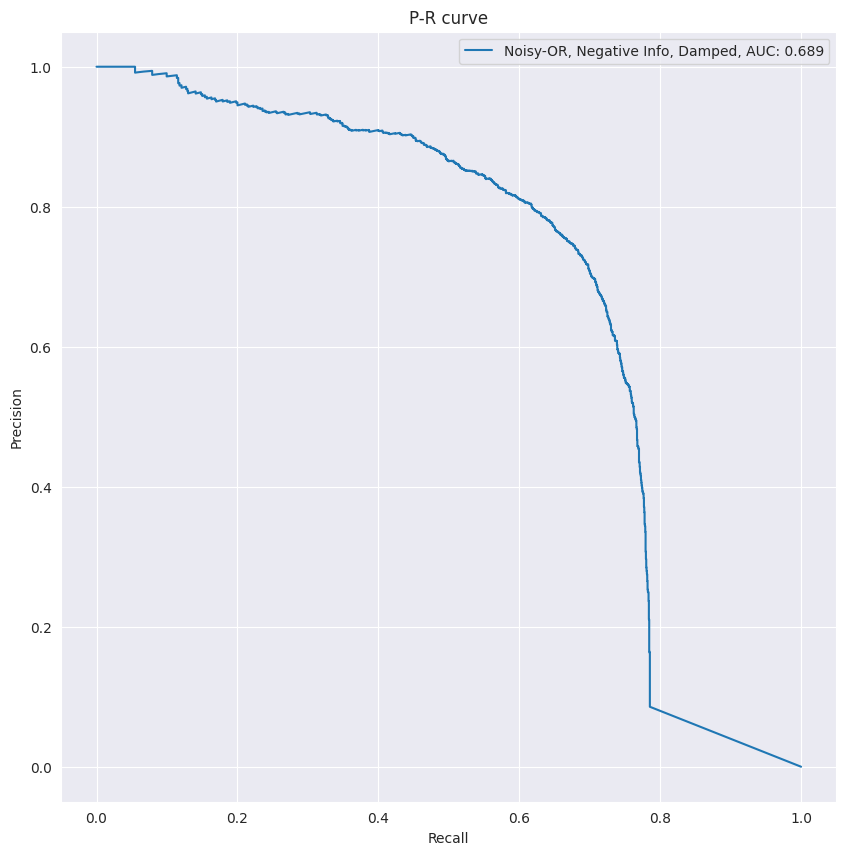

In [23]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr
selected_df["threshold"] = -np.log10(fpr) * selected_df["count_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"])
selected_df["pm6a_diff_damp"] = selected_df["pm6a_diff_damp"] * ((selected_df["pm6a_diff_damp"] > selected_df["threshold"]) & (selected_df["dom"] > 0.001))


fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


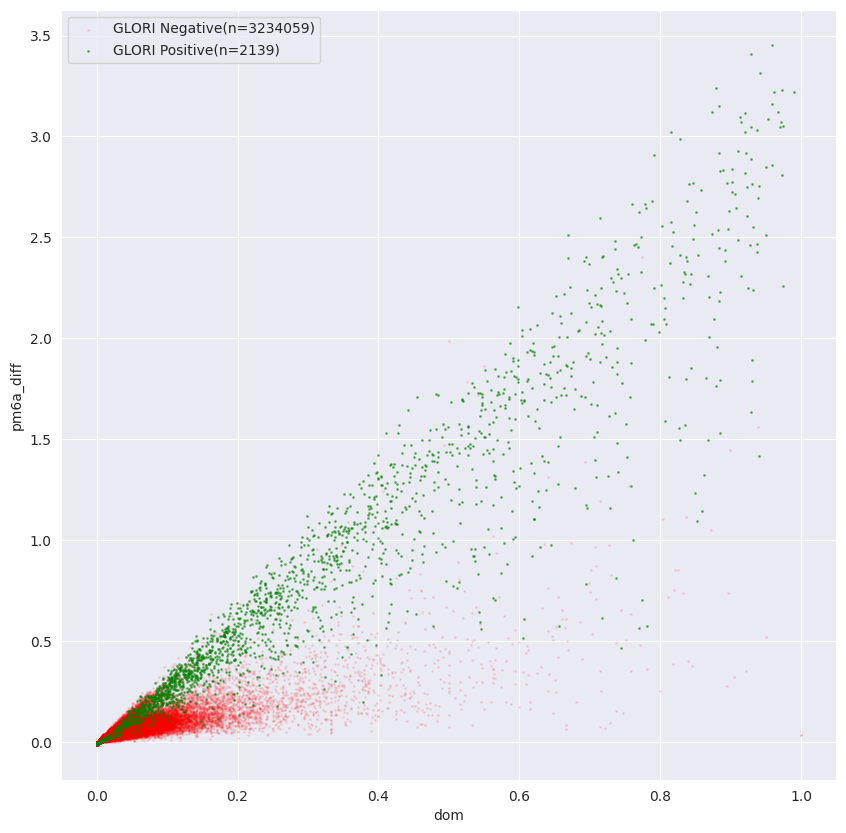

In [25]:
fpr = 0.003
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count"]) + selected_df["logsum_pca"]/(selected_df["count"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0] 

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})") 

ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

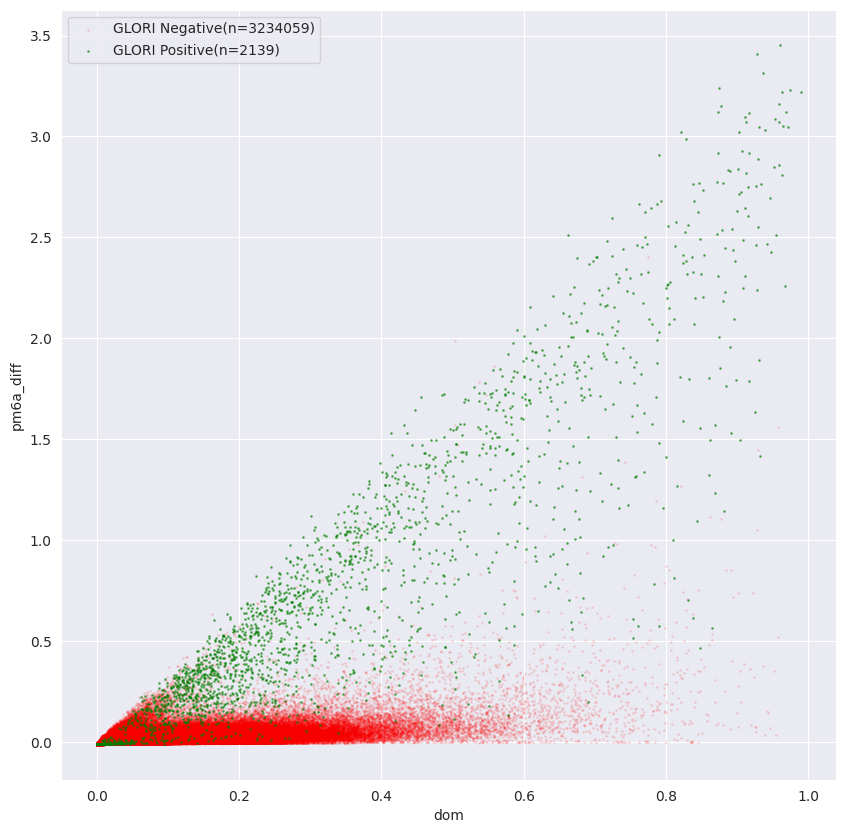

In [26]:
fpr = 0.003
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count"]) + selected_df["logsum_pca"]/(selected_df["count"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")

ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

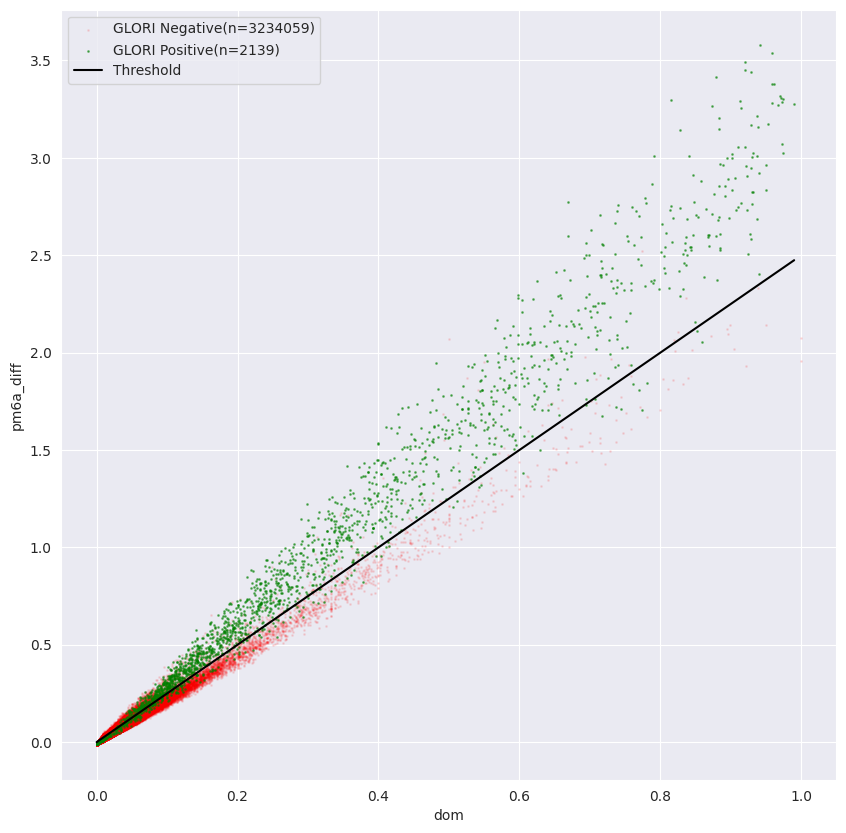

In [35]:
fpr = 0.0027

tnr = 0.8490

fpr_adj = fpr / (fpr + tnr)
tnr_adj = 1 - fpr_adj

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * tnr_adj + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * fpr_adj

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]


x = np.arange(0,1,0.01)
y = -np.log10(fpr_adj) * x

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.plot(x, y, color="black", label="Threshold")

ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close()

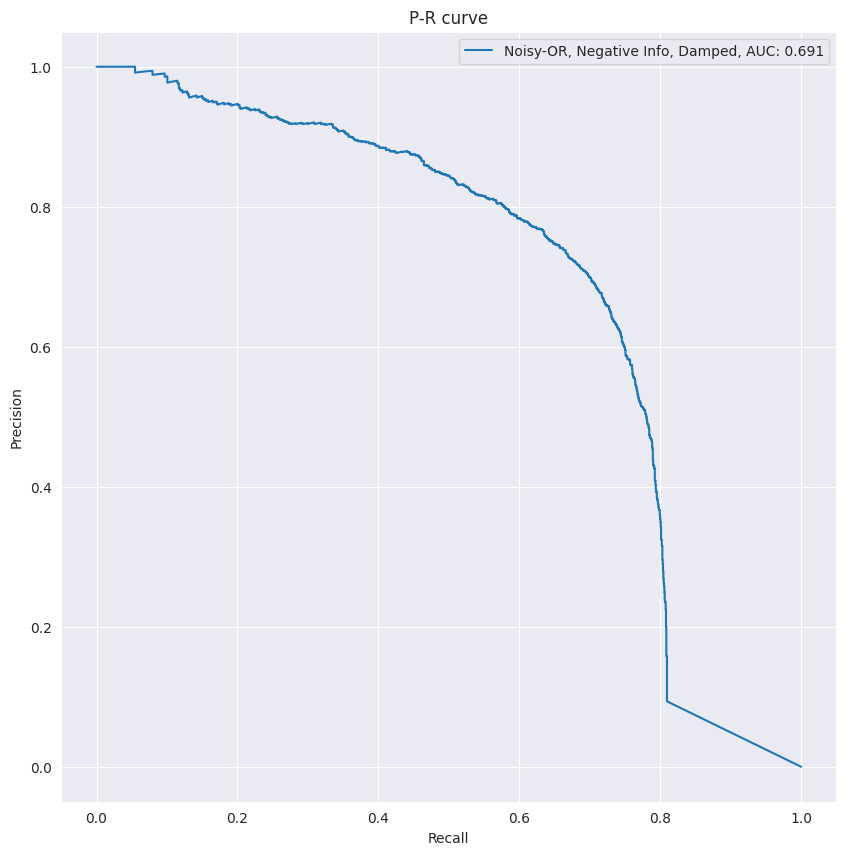

In [41]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027
tnr = 0.8490
fpr_adj = fpr / (fpr + tnr)
tnr_adj = 1 - fpr_adj

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)] 
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * tnr_adj + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * fpr_adj
selected_df["threshold"] = -np.log10(fpr_adj) * selected_df["count_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"])
selected_df["pm6a_diff_damp"] = selected_df["pm6a_diff_damp"] * (selected_df["pm6a_diff_damp"] > selected_df["threshold"]) 


fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [42]:
pca_50_50_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pca_50_50/pileup.npz"
with np.load(pca_50_50_df, allow_pickle=True) as data:
    pca_50_50_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_50_50_df = pca_50_50_df[pca_50_50_df["count_dom"] >= 20]
pca_50_50_df = pca_50_50_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_50_50_df)

FileNotFoundError: [Errno 2] No such file or directory: '/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pca_50_50/pileup.npz'

In [43]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.041

selected_df = pca_50_50_df[(~pca_50_50_df["drach"]) & (pca_50_50_df["count_dom"] >= 100) & (pca_50_50_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


TypeError: string indices must be integers

In [ ]:
fpr = 0.041
selected_df = pca_50_50_df[(~pca_50_50_df["drach"]) & (pca_50_50_df["count_dom"] >= 100) & (pca_50_50_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

In [ ]:
pca_20_90_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pca_50_50/pileup.npz"
with np.load(pca_20_90_df, allow_pickle=True) as data:
    pca_20_90_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_20_90_df = pca_20_90_df[pca_50_50_df["count_dom"] >= 20]
pca_20_90_df = pca_20_90_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_20_90_df)

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0096

selected_df = pca_20_90_df[(~pca_20_90_df["drach"]) & (pca_20_90_df["count_dom"] >= 100) & (pca_20_90_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [ ]:
fpr = 0.041
selected_df = pca_20_90_df[(~pca_20_90_df["drach"]) & (pca_20_90_df["count_dom"] >= 100) & (pca_20_90_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

In [ ]:
pca_50_98_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pca_50_50/pileup.npz"
with np.load(pca_50_98_df, allow_pickle=True) as data:
    pca_50_98_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_50_98_df = pca_50_98_df[pca_50_50_df["count_dom"] >= 20]
pca_50_98_df = pca_50_98_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_50_98_df)

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_50_98_df[(~pca_50_98_df["drach"]) & (pca_50_98_df["count_dom"] >= 100) & (pca_50_98_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [ ]:
fpr = 0.041
selected_df = pca_50_98_df[(~pca_50_98_df["drach"]) & (pca_50_98_df["count_dom"] >= 100) & (pca_50_98_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 